In [13]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np
import random
import clip
import seaborn as sns
from PIL import Image
import scipy.stats as stats
import umap
import plotly.express as px

In [14]:
df = pd.read_parquet('../data/articles.parquet')


#### Color Analysis
Colors were preprocessed previously, but I'm now going to understand their textual presentation in the dataset. 
Mainly, for hues we have three-level lightness decomposition: e.g., Light Blue -> Blue -> Dark Blue. Thus, no obviously overlapping color categories (like Dark Blue vs Navy) are present.

There are color labels of the form "Other X". Direct inspection of samples from them as opposed to "X" categories showed, that labelers had some idea of a color "X" and when the object showed any discrepancies, but still was attributed to that hue in general, they'd label it as "Other X". 

For example, many objects in the Blue category are dull blues, while Other Blue category contains more vibrant blues (but not necessarily only them, see the samples below). The same is even more obvious for Yellow category with dull or mustard samples, where a sample from Other Yellow category contained acid yellows exclusively. "Other X" also contains noise, e.g., there are grey/purple objects found in the Other Blue category and multicolored objects found in the Other Purple one.

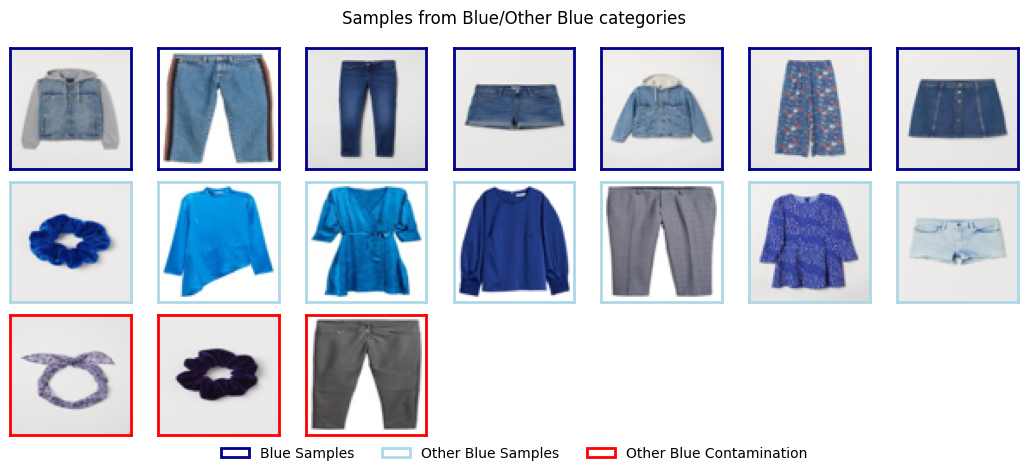

In [15]:
from src.utils import create_category_comparison_grid
from src import config

fig = create_category_comparison_grid(
    category_paths_dict=config.BLUE_SAMPLES,
    border_colors=config.BLUE_BORDER_COLORS,
    title='Samples from Blue/Other Blue categories',
    images_per_row=7,  
    image_size=(70, 70),
)

It's reasonable to suspect, that contaminating noise is not unique to the Other Blue/Other Purple categories, which are easy to parse due to small size. This makes all "Other X" categories unreliable, but they still contain unique colors, which makes them necessary.

In [16]:
other_colors = df[df['colour_group_name'].str.contains('Other', na=False)]
print(other_colors['colour_group_name'].value_counts())
print('-'*60)
print('Items of "Other X" color type overall:')
len(df[df['colour_group_name'].str.contains('Other', na=False)])

colour_group_name
Other Pink         739
Other Yellow       224
Other Orange       151
Other Green        125
Other Red          113
Other Blue          51
Other Purple        45
Other Turquoise     14
Name: count, dtype: int64
------------------------------------------------------------
Items of "Other X" color type overall:


1462

Although "Other X" label is noisy, it represents ~1.5% of the training data. FashionCLIP was trained on 700k examples, so training it using 1500 potentially noisy points shouldn't meaningfully distort its solid pretrained manifold.

"Other X" is not very semantically meaningful, but I expect the model to utilize image embeddings and learn what "Other X" labels mean.

Let's dive into color distribution.

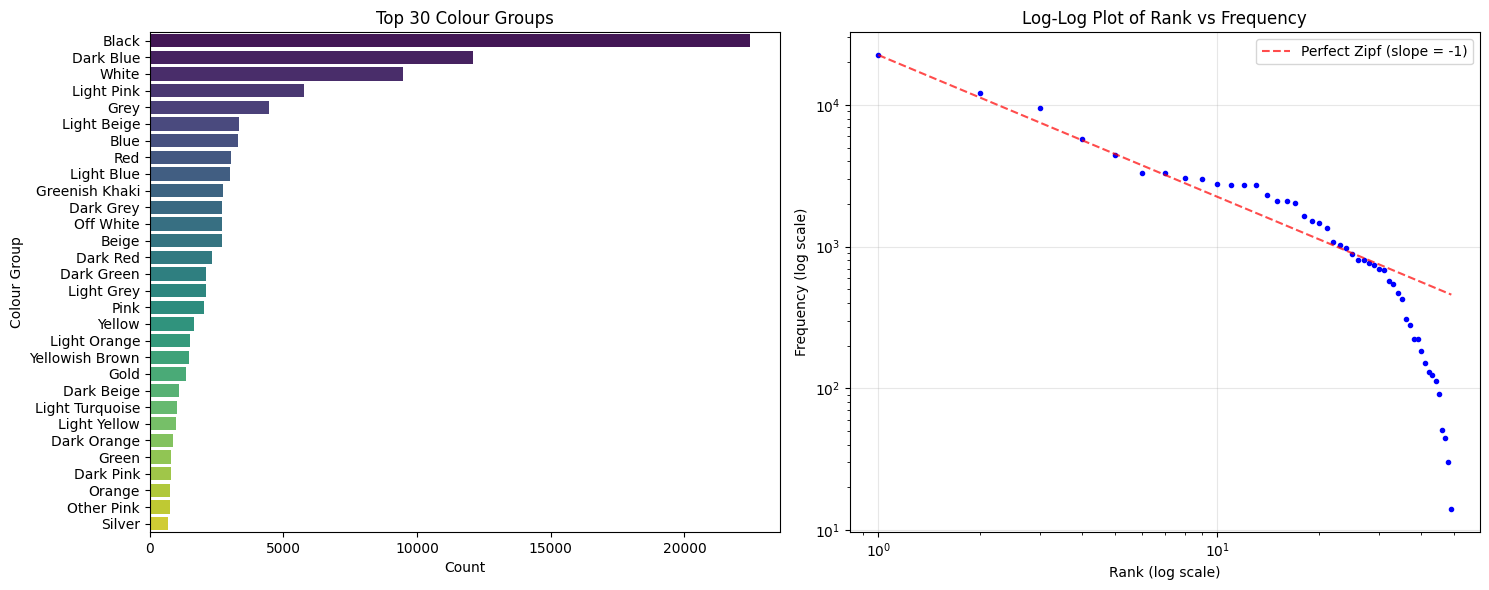

Total unique colors: 49
CONCENTRATIONS:
   Top 1 color (Black): 21.4% of all items
   Top 5 colors: 51.8% of all items
   Top 10 colors: 66.5% of all items
   Top 20 colors: 86.8% of all items
   Top 30 colors: 95.5% of all items
LONG TAIL:
   Colors with < 1000 items: 26 (53.1% of all colors)
   Total items in long tail: 10,346 (9.9% of all items)


In [17]:
color_counts = df['colour_group_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top30_color_groups = color_counts.head(30)
sns.barplot(x=top30_color_groups.values, y=top30_color_groups.index, 
            hue=top30_color_groups.index, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Top 30 Colour Groups')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Colour Group')

ranks = np.arange(1, len(color_counts) + 1)
freqs = color_counts.values

axes[1].loglog(ranks, freqs, 'b.')
axes[1].set_xlabel('Rank (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Log-Log Plot of Rank vs Frequency')
axes[1].grid(True, alpha=0.3)

# Add reference line for perfect Zipf (slope = -1)
axes[1].loglog(ranks, freqs[0]/ranks, 'r--', alpha=0.7, label='Perfect Zipf (slope = -1)')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Total unique colors: {len(color_counts)}")

top1_pct = (color_counts.iloc[0] / len(df)) * 100
top5_pct = (color_counts.head(5).sum() / len(df)) * 100
top10_pct = (color_counts.head(10).sum() / len(df)) * 100
top20_pct = (color_counts.head(20).sum() / len(df)) * 100
top30_pct = (color_counts.head(30).sum() / len(df)) * 100

print('CONCENTRATIONS:')
print(f"   Top 1 color ({color_counts.index[0]}): {top1_pct:.1f}% of all items")
print(f"   Top 5 colors: {top5_pct:.1f}% of all items")
print(f"   Top 10 colors: {top10_pct:.1f}% of all items")
print(f"   Top 20 colors: {top20_pct:.1f}% of all items")
print(f"   Top 30 colors: {top30_pct:.1f}% of all items")

rare_colors = color_counts[color_counts < 1000]
print('LONG TAIL:')
print(f"   Colors with < 1000 items: {len(rare_colors)} ({len(rare_colors)/len(color_counts)*100:.1f}% of all colors)")
print(f"   Total items in long tail: {rare_colors.sum():,} ({rare_colors.sum()/len(df)*100:.1f}% of all items)")

The distribution is highly skewed, Zipf-like (especially for initial colors), contains regions of roughly uniform count (e.g., \[Beige, Greenish Khaki\] interval). As a result, ~40% of initial colors accrue 86.8% of all items. The tail decays much faster than in the perfect Zipf case, slightly more than half the colors are rare and associated items constitute only a small volume. Black accounts for ~1/5 and top 5 neutral colors attribute ~1/2 of the dataset. 

The distribution of neutral tones supports the narutral distribution in a mass market, where clothes cluster around "safe" colors.

#### Product Analysis
Just like with colors, product types have values of the form "Other X", which was demonstrated during cleaining. However, the level of inconsistency within product types is even higher, for example:
* `Dog wear` vs `Dog Wear`
* `Flat shoe` vs `Flat shoes`
* `Hair/alice band` vs `Alice band` vs `Headband` vs `Hairband` vs `Hair string`

I've decided not to collide them, because
1. capitalized or pluralized product values are semantically equivalent to their lowercase or singular counterparts;
2. colliding seemingly ambiguous names may lead to noisy categories, since I'm unaware of how exactly names are assigned to products.

Instead, again, I suppose that the model itself will be able to infer the naming conventions from the images of products. 

Let's analyze product distribution.

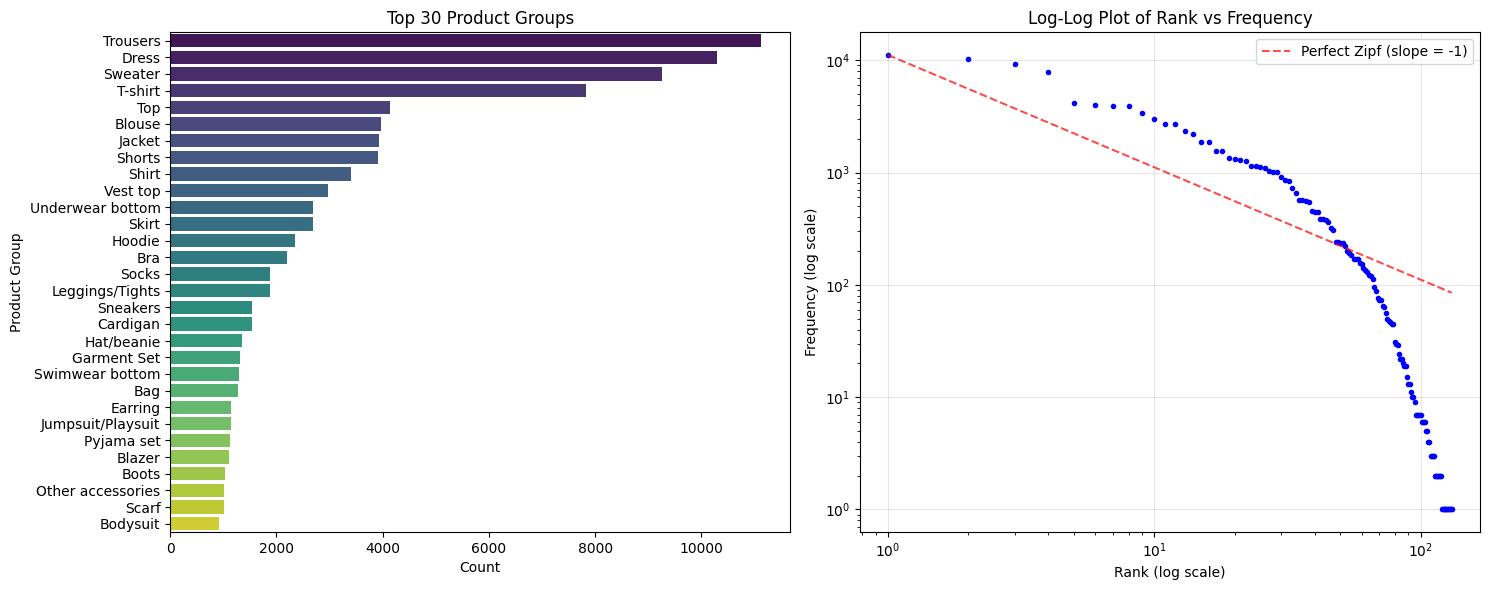

Total unique product types: 131
CONCENTRATIONS:
   Top 1 product (Trousers): 10.6% of all items
   Top 5 products: 40.7% of all items
   Top 10 products: 58.1% of all items
   Top 20 products: 76.7% of all items
   Top 30 products: 87.2% of all items
LONG TAIL:
   Products with < 1000 items: 102 (77.9% of all products)
   Total items in long tail: 14,293 (13.7% of all items)


In [18]:
product_counts = df['product_type_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top30_product_groups = product_counts.head(30)
sns.barplot(x=top30_product_groups.values, y=top30_product_groups.index, 
            hue=top30_product_groups.index, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Top 30 Product Groups')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Product Group')

ranks = np.arange(1, len(product_counts) + 1)
freqs = product_counts.values

axes[1].loglog(ranks, freqs, 'b.')
axes[1].set_xlabel('Rank (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Log-Log Plot of Rank vs Frequency')
axes[1].grid(True, alpha=0.3)

# Add reference line for perfect Zipf (slope = -1)
axes[1].loglog(ranks, freqs[0]/ranks, 'r--', alpha=0.7, label='Perfect Zipf (slope = -1)')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Total unique product types: {len(product_counts)}")

top1_pct = (product_counts.iloc[0] / len(df)) * 100
top5_pct = (product_counts.head(5).sum() / len(df)) * 100
top10_pct = (product_counts.head(10).sum() / len(df)) * 100
top20_pct = (product_counts.head(20).sum() / len(df)) * 100
top30_pct = (product_counts.head(30).sum() / len(df)) * 100

print('CONCENTRATIONS:')
print(f"   Top 1 product ({product_counts.index[0]}): {top1_pct:.1f}% of all items")
print(f"   Top 5 products: {top5_pct:.1f}% of all items")
print(f"   Top 10 products: {top10_pct:.1f}% of all items")
print(f"   Top 20 products: {top20_pct:.1f}% of all items")
print(f"   Top 30 products: {top30_pct:.1f}% of all items")

rare_products = product_counts[product_counts < 1000]
print('LONG TAIL:')
print(f"   Products with < 1000 items: {len(rare_products)} ({len(rare_products)/len(product_counts)*100:.1f}% of all products)")
print(f"   Total items in long tail: {rare_products.sum():,} ({rare_products.sum()/len(df)*100:.1f}% of all items)")

The distribution is skewed, with deviations from Zipf's decay on both sides. Initial types accrue dominance much faster than in the case of colors; ~15% of product types constitute 76.7% of all items, but the distribution of items within those types is more uniform. More than 3/4 of product types are rare and constitute a small volume of all items. Trousers account for ~1/10 and top 10 types cover more than a half of the dataset.

Garments are represented more. However, interestingly, T-shirt type is forth most frequent one with 7825 items, but was demonstrated to be one of the most underdescribed (17.3 words), which lowers its semantic signal.

On the other hand, some types like Scarf (15 words), Earring (16.2 words), Hat/beanie (17.4 words), Leggings/Tights (19.6 words) are infrequent (~1000 items) and underdescribed at the same time, introducing correlated scarcity.

#### Color-Product Distribution Analysis
At the end, let's look at the joint distribution $p(\mathsf{P}, \mathsf{C})$ for product $\mathsf{P}$, color $\mathsf{C}$.

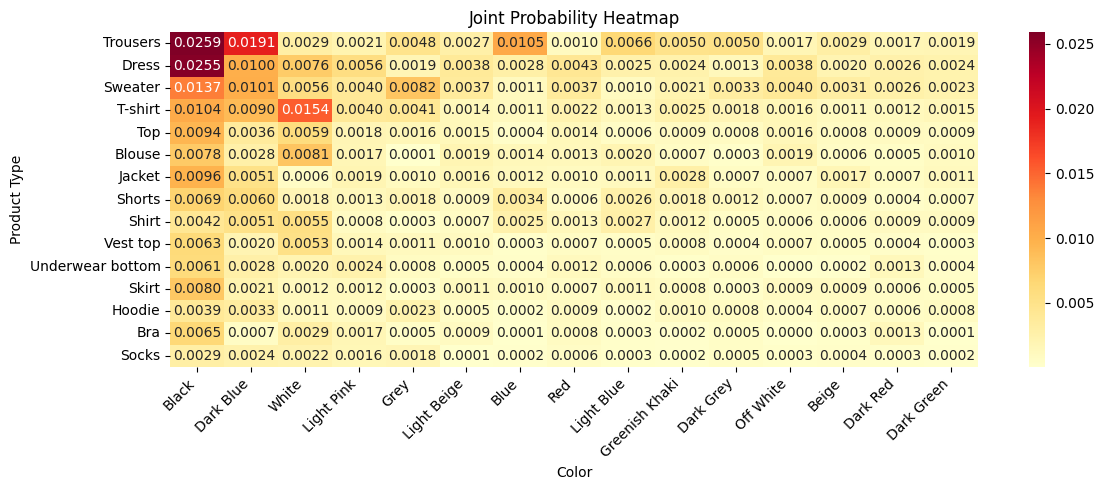

In [19]:
count_matrix = pd.crosstab(
    df['product_type_name'], 
    df['colour_group_name']
)
joint_probs = count_matrix / len(df)

# Take top N products and colors for readability
top_products = df['product_type_name'].value_counts().head(15).index
top_colors = df['colour_group_name'].value_counts().head(15).index
joint_probs_subset = joint_probs.loc[top_products, top_colors]

plt.figure(figsize=(12, 5))
sns.heatmap(
    joint_probs_subset,
    annot=True,           
    fmt='.4f',         
    cmap='YlOrRd',    
    linecolor='gray'
)

plt.title('Joint Probability Heatmap')
plt.xlabel('Color')
plt.ylabel('Product Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This heatmap is consistent with previous marginal analysis.